# Feature Engineering 

- Aggeration of the dataset which transform the transaction data we got into customer base dataset 

In [74]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 

In [22]:
cleaned_df = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\notebook\\cleaned_online_retail.csv",dtype={"StockCode":"str"})

In [23]:
cleaned_df["Sales"] = cleaned_df["Quantity"] * cleaned_df["Price"]

In [24]:
cleaned_df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
2,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
3,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
4,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# Generate aggregate df with RFM framework 

In [25]:
agg_cleaned_df = cleaned_df.groupby("Customer ID").agg(
    Country = ("Country", "first"),
    Total_sales = ("Sales", "sum"),
    Frequency = ("Invoice","nunique"), # nunique = number of unique number 
    LastInvoiceDate = ("InvoiceDate", "max")
).reset_index() # reset_index() is use to reset the customer ID to normal column as it currently set as index 

In [26]:
agg_cleaned_df["Reference_date"] = agg_cleaned_df["LastInvoiceDate"].max()  # Anchor point for recency date 

In [ ]:
# Convert both string column into datetime data type
agg_cleaned_df["Reference_date"] = pd.to_datetime(agg_cleaned_df["Reference_date"],errors="coerce")
agg_cleaned_df["LastInvoiceDate"] = pd.to_datetime(agg_cleaned_df["LastInvoiceDate"],errors="coerce")

# Define the recency column
agg_cleaned_df["Recency"] = (agg_cleaned_df["Reference_date"] - agg_cleaned_df["LastInvoiceDate"]).dt.days

In [33]:
agg_cleaned_df.info()
agg_cleaned_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 4248 entries, 0 to 4247
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      4248 non-null   float64       
 1   Country          4248 non-null   str           
 2   Total_sales      4248 non-null   float64       
 3   Frequency        4248 non-null   int64         
 4   LastInvoiceDate  4248 non-null   datetime64[us]
 5   Reference_date   4248 non-null   datetime64[us]
 6   Recency          4248 non-null   int64         
dtypes: datetime64[us](2), float64(2), int64(2), str(1)
memory usage: 232.4 KB


,Customer ID,Country,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency
0,12346.0,United Kingdom,144.02,2,2010-06-28 13:53:00,2010-12-09 20:01:00,164
1,12347.0,Iceland,966.87,2,2010-12-07 14:57:00,2010-12-09 20:01:00,2
2,12348.0,Finland,221.16,1,2010-09-27 14:59:00,2010-12-09 20:01:00,73
3,12349.0,Italy,1946.64,2,2010-10-28 08:23:00,2010-12-09 20:01:00,42
4,12351.0,Unspecified,300.93,1,2010-11-29 15:23:00,2010-12-09 20:01:00,10


# Identify Outlier and distribution 

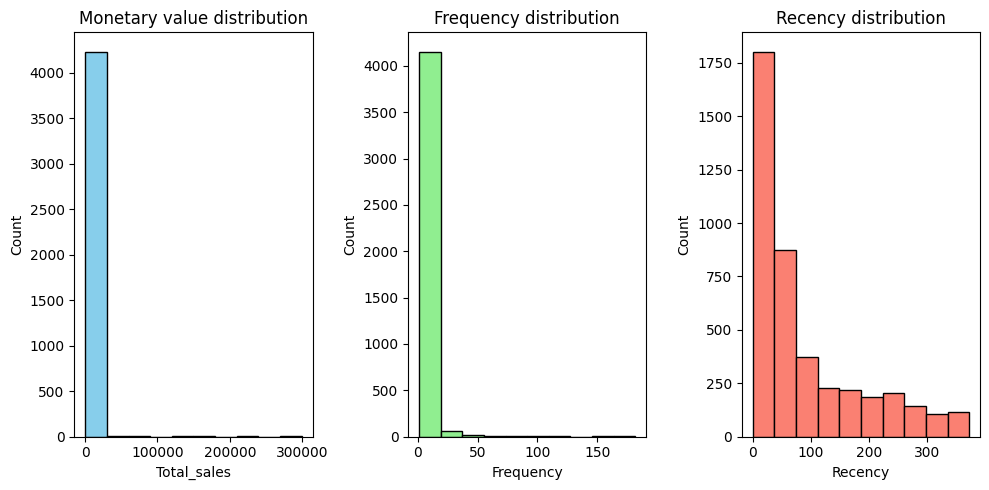

In [71]:
# Identify the distribution with histogram visualization

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.hist(agg_cleaned_df["Total_sales"], bins=10,color="skyblue",edgecolor="black")
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")
plt.ylabel("Count")

plt.subplot(1,3,2)
plt.hist(agg_cleaned_df["Frequency"], bins=10,color="lightgreen",edgecolor="black")
plt.title("Frequency distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(1,3,3)
plt.hist(agg_cleaned_df["Recency"], bins=10,color="salmon",edgecolor="black")
plt.title("Recency distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

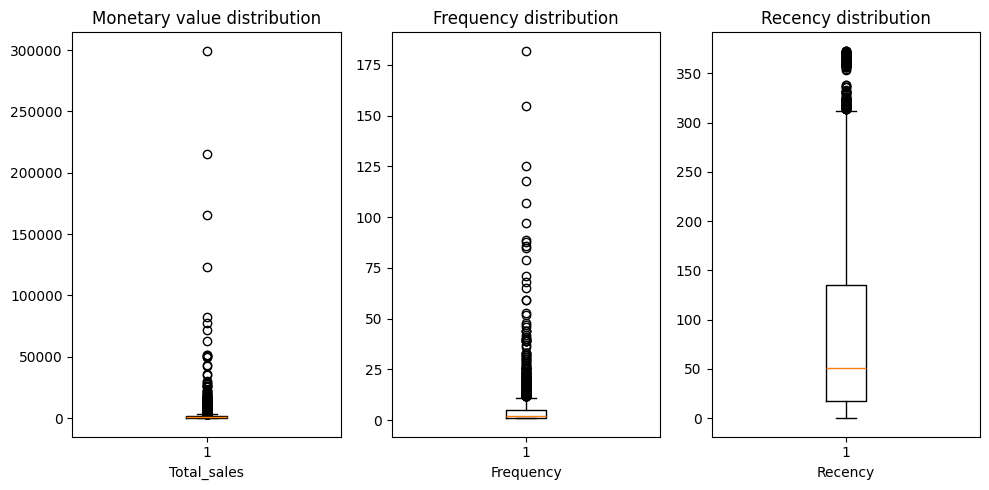

In [70]:
# Identify the outlier with boxplot

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.boxplot(agg_cleaned_df["Total_sales"])
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")


plt.subplot(1,3,2)
plt.boxplot(agg_cleaned_df["Frequency"])
plt.title("Frequency distribution")
plt.xlabel("Frequency")


plt.subplot(1,3,3)
plt.boxplot(agg_cleaned_df["Recency"])
plt.title("Recency distribution")
plt.xlabel("Recency")


plt.tight_layout()
plt.show()

In [61]:
# Determine total sales column outlier with IQR

S_01  = agg_cleaned_df["Total_sales"].quantile(0.25) 
S_03  = agg_cleaned_df["Total_sales"].quantile(0.75)
S_IQR = S_03 - S_01

S_outlier_df = agg_cleaned_df[(agg_cleaned_df["Total_sales"]>(S_03 + 1.5 * S_IQR))]
S_outlier_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Customer ID,412.0,15083.296117,12357.0,13561.75,14956.5,16653.0,18260.0,1733.822102
Total_sales,412.0,10433.185937,3308.9,3957.3,5389.85,8847.1825,299485.8,22291.545824
Frequency,412.0,17.033981,1.0,8.0,12.0,18.0,182.0,19.376882
LastInvoiceDate,412,2010-11-10 21:01:28.106796,2009-12-10 18:03:00,2010-11-08 13:45:45,2010-11-26 15:03:30,2010-12-06 12:47:30,2010-12-09 19:32:00,NaN
Reference_date,412,2010-12-09 20:01:00,2010-12-09 20:01:00,2010-12-09 20:01:00,2010-12-09 20:01:00,2010-12-09 20:01:00,2010-12-09 20:01:00,NaN
Recency,412.0,28.674757,0.0,3.0,13.0,31.0,364.0,49.154417


In [60]:
# Determine Frequency column Outlier with InterQuatileRange 

F_Q1 = agg_cleaned_df["Frequency"].quantile(0.25)
F_Q3 = agg_cleaned_df["Frequency"].quantile(0.75)
F_IQR = F_Q3 - F_Q1

F_outlier_df = agg_cleaned_df[(agg_cleaned_df["Frequency"] > (F_Q3 + 1.5 * F_IQR))]

F_outlier_df.describe()

,Customer ID,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency
count,269.000000,269.000000,269.000000,269,269,269.000000
mean,15392.802974,12298.980725,23.698885,2010-11-23 16:23:39.033457,2010-12-09 20:01:00,15.866171
min,12437.000000,898.140000,12.000000,2010-05-12 16:51:00,2010-12-09 20:01:00,0.000000
25%,13831.000000,3638.010000,13.000000,2010-11-21 10:38:00,2010-12-09 20:01:00,2.000000
50%,15527.000000,5572.670000,17.000000,2010-12-02 12:09:00,2010-12-09 20:01:00,7.000000
75%,16883.000000,10269.460000,24.000000,2010-12-07 12:43:00,2010-12-09 20:01:00,18.000000
max,18260.000000,299485.800000,182.000000,2010-12-09 19:32:00,2010-12-09 20:01:00,211.000000
std,1748.380712,27198.754282,21.578787,NaN,NaN,26.789616


In [ ]:
# Determine Recency column Outlier with InterQuatileRange 

R_Q1 = agg_cleaned_df["Recency"].quantile(0.25)
R_Q3 = agg_cleaned_df["Recency"].quantile(0.75)
R_IQR = R_Q3 - R_Q1

R_outlier_df = agg_cleaned_df[(agg_cleaned_df["Recency"] > (R_Q3 + 1.5 * R_IQR))]

R_outlier_df.describe().T

# Recency show normal outlier behavior 

,count,mean,min,25%,50%,75%,max,std
Customer ID,167.0,15401.508982,12439.0,14115.5,15380.0,16782.5,18201.0,1620.566768
Total_sales,167.0,307.531204,2.95,101.4,183.08,313.605,4825.68,529.119527
Frequency,167.0,1.245509,1.0,1.0,1.0,1.0,6.0,0.756236
LastInvoiceDate,167,2009-12-24 02:49:12.934131,2009-12-01 12:55:00,2009-12-07 13:28:00,2009-12-14 16:11:00,2010-01-16 13:27:30,2010-01-29 14:22:00,NaN
Reference_date,167,2010-12-09 20:01:00,2010-12-09 20:01:00,2010-12-09 20:01:00,2010-12-09 20:01:00,2010-12-09 20:01:00,2010-12-09 20:01:00,NaN
Recency,167.0,350.431138,314.0,327.0,360.0,367.0,373.0,20.647494


In [ ]:
# Outlier separation  
# Do not seperate the outlier of recency as it show normal outlier genuinely inactive customer which is valuable info for segmentation.
non_outlier_df = agg_cleaned_df[
    (~ agg_cleaned_df.index.isin(F_outlier_df.index)) & 
    (~ agg_cleaned_df.index.isin(S_outlier_df.index))
]

non_outlier_df.describe()

,Customer ID,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency
count,3785.000000,3785.000000,3785.000000,3785,3785,3785.000000
mean,15372.177279,773.150842,2.856539,2010-09-03 14:28:03.788639,2010-12-09 20:01:00,96.949538
min,12346.000000,2.950000,1.000000,2009-12-01 12:55:00,2010-12-09 20:01:00,0.000000
25%,13909.000000,236.400000,1.000000,2010-07-08 16:56:00,2010-12-09 20:01:00,22.000000
50%,15379.000000,508.570000,2.000000,2010-10-12 17:17:00,2010-12-09 20:01:00,58.000000
75%,16847.000000,1115.970000,4.000000,2010-11-17 13:42:00,2010-12-09 20:01:00,154.000000
max,18287.000000,3298.600000,11.000000,2010-12-09 20:01:00,2010-12-09 20:01:00,373.000000
std,1691.821226,714.336213,2.232585,NaN,NaN,98.123638


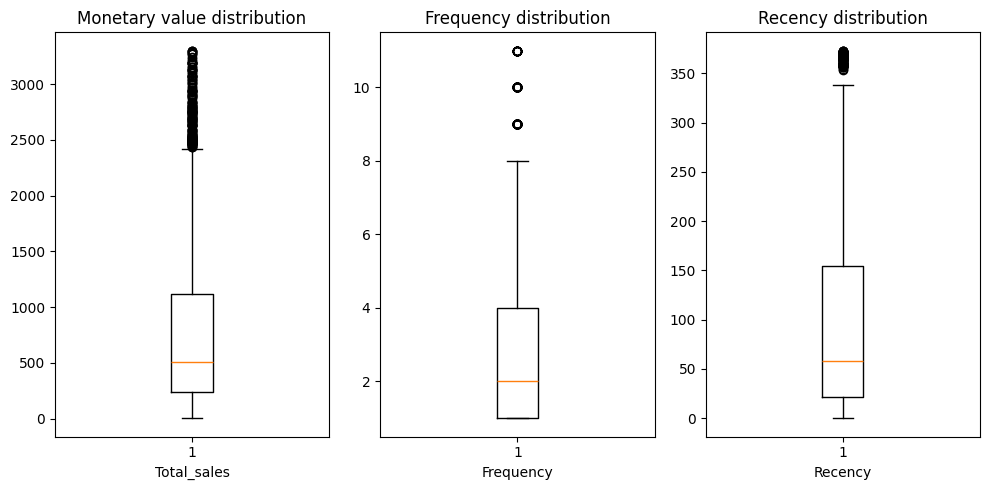

In [69]:
# To check outlier again after filtering 

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.boxplot(non_outlier_df["Total_sales"])
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")


plt.subplot(1,3,2)
plt.boxplot(non_outlier_df["Frequency"])
plt.title("Frequency distribution")
plt.xlabel("Frequency")


plt.subplot(1,3,3)
plt.boxplot(non_outlier_df["Recency"])
plt.title("Recency distribution")
plt.xlabel("Recency")


plt.tight_layout()
plt.show()

Text(0.5, 0.92, '3D Scatter plot of Customer data')

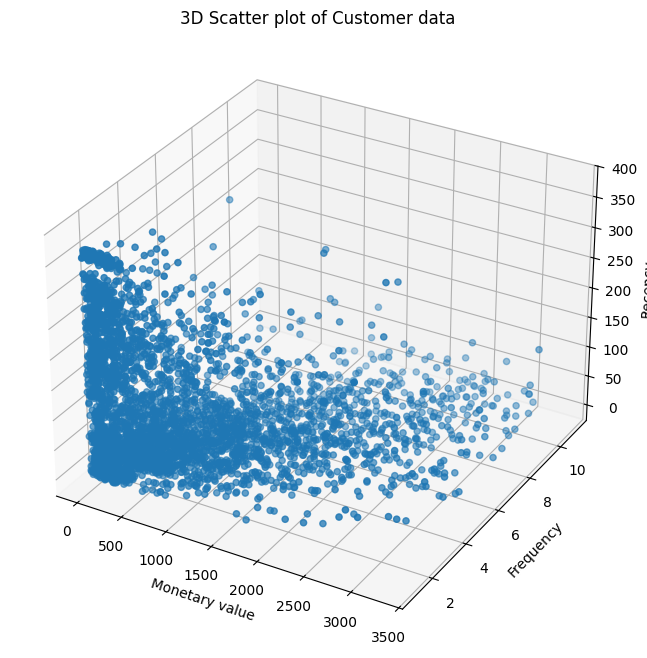

In [ ]:
# Visualise the non outlier dataframe in 3D scatter plot (Not-scale yet)
 
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(non_outlier_df["Total_sales"],non_outlier_df["Frequency"],non_outlier_df["Recency"])
ax.set_xlabel("Monetary value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter plot of Customer data")


In [ ]:
# Data transformation with stantard scaler 
# Without scale the monetary id completely dominate which the centroid would draw more to monetary value 
# create a unfair goruping, we want our algorithm to treat all features with equal weight and important

scaler = StandardScaler()
rfm_scaled_data = scaler.fit_transform(non_outlier_df[["Recency","Frequency","Total_sales"]])
rfm_scaled_data # this return a series of array

array([[ 0.68341659, -0.3837042 , -0.88083728],
       [-0.96777989, -0.3837042 ,  0.27122348],
       [-0.24410736, -0.83167471, -0.77283465],
       ...,
       [ 2.01864337, -0.83167471, -0.57690661],
       [ 0.14321033, -0.3837042 ,  0.24522388],
       [-0.81489133,  0.51223682,  1.07896109]], shape=(3785, 3))

In [78]:
# convert into dataframe

scaled_data_df =pd.DataFrame(rfm_scaled_data,index=non_outlier_df.index,columns=["Monetary_value","Frequency","Recency"])
scaled_data_df

,Monetary_value,Frequency,Recency
0,0.683417,-0.383704,-0.880837
1,-0.967780,-0.383704,0.271223
2,-0.244107,-0.831675,-0.772835
3,-0.560077,-0.383704,1.642986
4,-0.886239,-0.831675,-0.661150
...,...,...,...
4243,-0.814891,1.408178,-0.293963
4244,-0.315455,-0.831675,-0.534652
4245,2.018643,-0.831675,-0.576907
4246,0.143210,-0.383704,0.245224


Text(0.5, 0.92, '3D scatter plot for customer data')

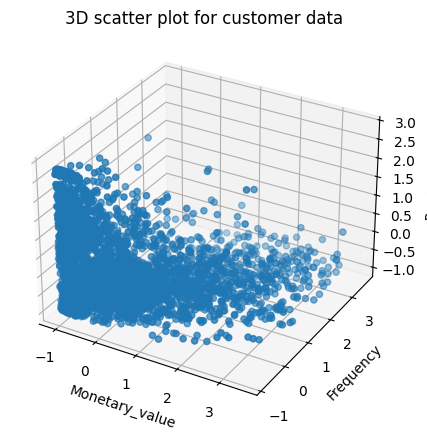

In [81]:
# Visualised the scaled dataframe

fig = plt.figure(figsize=(5,10))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(scaled_data_df["Recency"],scaled_data_df["Frequency"],scaled_data_df["Monetary_value"])
ax.set_xlabel("Monetary_value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D scatter plot for customer data")